In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

PICKLE_DIR = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles'

# Stimulus-type colours
STIM_COLS = {
    'constant': '#2E7D32',   # dark green
    'ramp':     '#9933CC',   # purple
    'pink':     '#FF44CC',   # hot pink
}
STIM_ORDER  = ['constant', 'ramp', 'pink']
STIM_LABELS = {'constant': 'Constant', 'ramp': 'Ramp', 'pink': 'Pink noise'}

# Cell labels (from CRCNS PVC-6 data description)
CELL_LABELS = {
    1: 'Cell 1 (SST+)',      # 153098.04.02 — Somatostatin-positive
    2: 'Cell 2 (unmarked)',  # 151145.04    — Unmarked
}

FS_TITLE = 11
FS_LABEL = 10
FS_TICK  = 9
FS_ANNOT = 8

In [2]:
# ── Load pickles and build per-sweep summary ───────────────────────────────────
fs = 200000

cells = {}
for cnum, suffix in [(1, ''), (2, '2')]:
    with open(f'{PICKLE_DIR}/df_stim_features{suffix}.pkl', 'rb') as f:
        df = pickle.load(f)
    with open(f'{PICKLE_DIR}/all_data{suffix}.pkl', 'rb') as f:
        all_data = pickle.load(f)

    sweep_dur = {sweep: len(all_data[int(sweep)]) / fs
                 for sweep in df['sweep'].unique()}

    per_sweep = (df.groupby(['sweep', 'stim_type'])['spike_num']
                   .count()
                   .reset_index()
                   .rename(columns={'spike_num': 'n_spikes'}))
    per_sweep['duration_s'] = per_sweep['sweep'].map(sweep_dur)
    per_sweep['fr_hz']      = per_sweep['n_spikes'] / per_sweep['duration_s']
    per_sweep['cell']       = f'Cell {cnum}'

    pink_variants = (df[df['stim_type'] == 'pink']['pink_type'].nunique()
                     if 'pink_type' in df.columns else np.nan)

    cells[cnum] = dict(df=df, per_sweep=per_sweep, pink_variants=pink_variants)

    # Print quick summary
    print(f'\n=== Cell {cnum} ===')
    print(f'  Total spikes : {len(df)}')
    print(f'  Spikes / stim type:')
    print(df['stim_type'].value_counts().to_string())
    print(f'  Sweeps / stim type:')
    print(df.groupby('stim_type')['sweep'].nunique().to_string())
    print(f'  Pink noise variants: {pink_variants}')


=== Cell 1 ===
  Total spikes : 820
  Spikes / stim type:
stim_type
pink        418
constant    233
ramp        169
  Sweeps / stim type:
stim_type
constant    20
pink        27
ramp         5
  Pink noise variants: 10

=== Cell 2 ===
  Total spikes : 380
  Spikes / stim type:
stim_type
pink        296
constant     82
ramp          2
  Sweeps / stim type:
stim_type
constant    16
pink        26
ramp         1
  Pink noise variants: 9


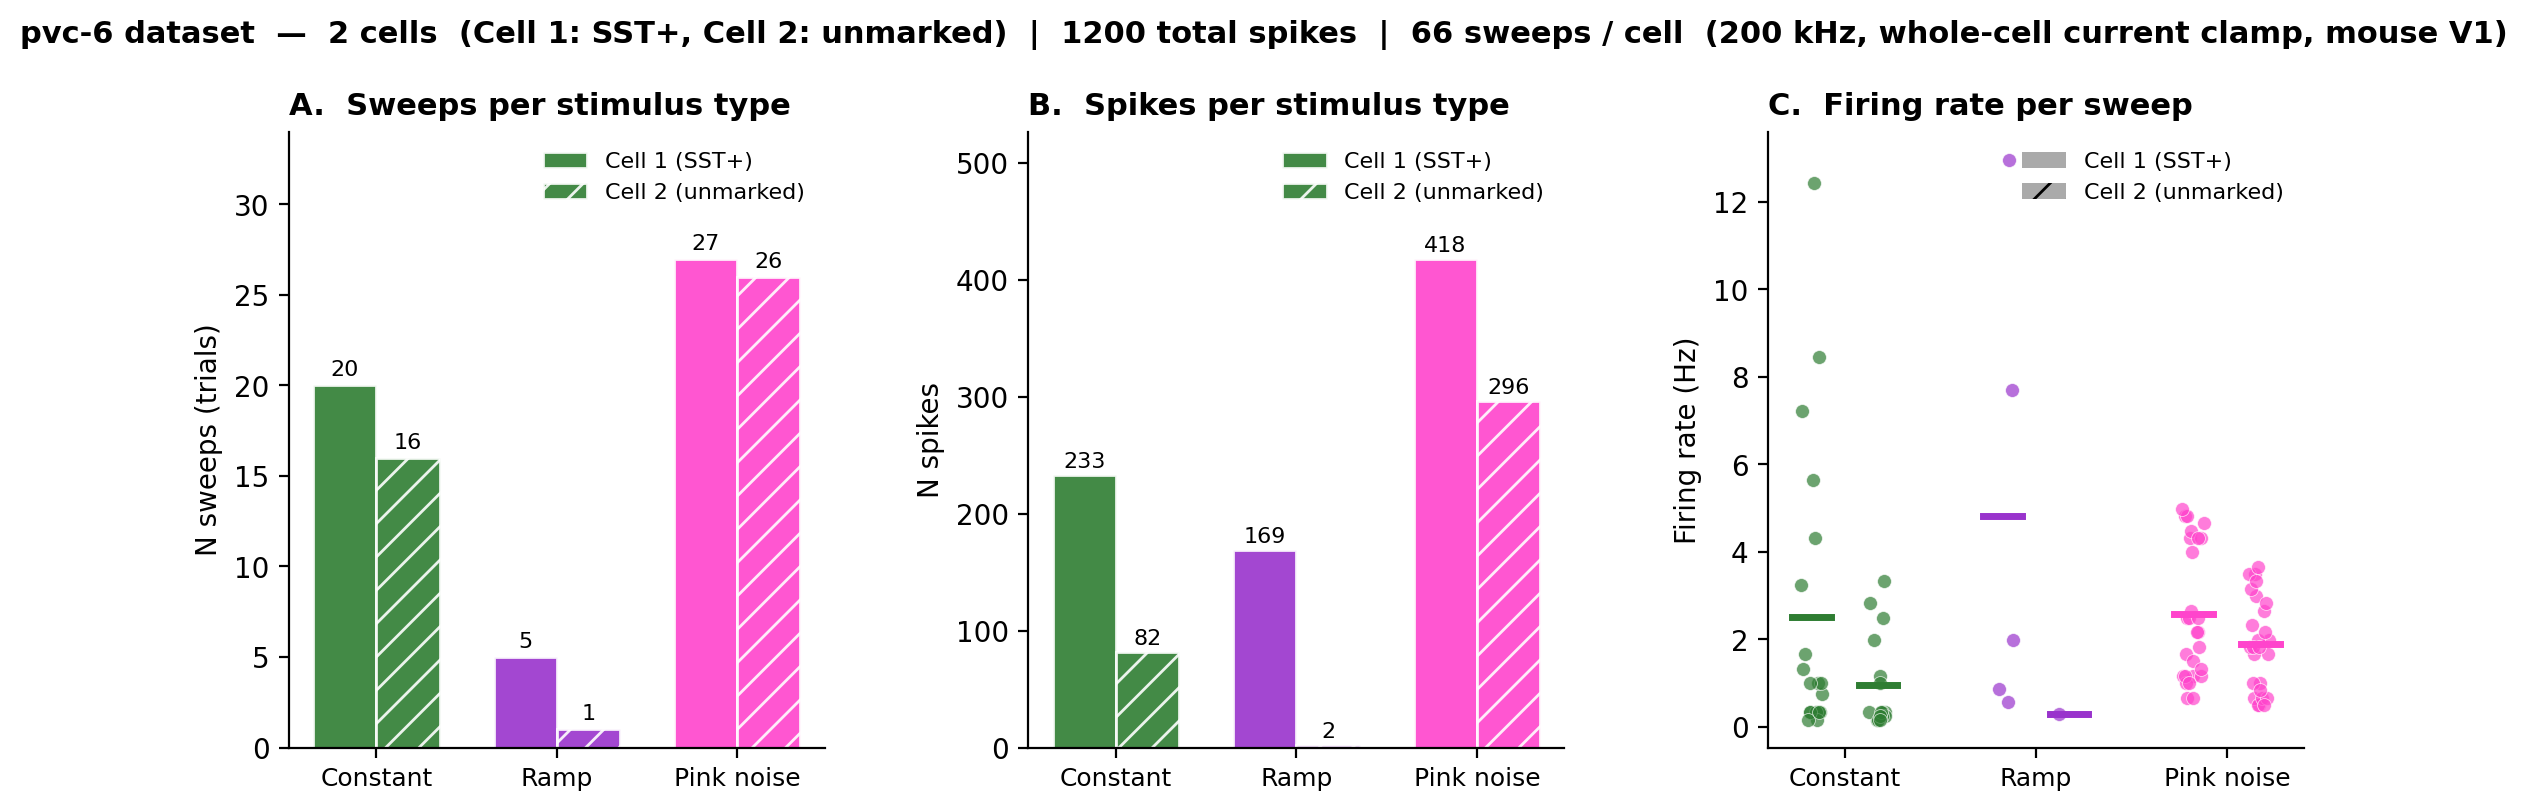

Saved.


In [3]:
# ── Figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

CELL_HATCHES = ['', '//']
x            = np.arange(len(STIM_ORDER))
bar_w        = 0.35
offsets      = [-bar_w/2, bar_w/2]

# ── A. N sweeps per stim type ──────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0])
for ci, (cnum, hatch) in enumerate(zip([1, 2], CELL_HATCHES)):
    df = cells[cnum]['df']
    sweep_counts = df.groupby('stim_type')['sweep'].nunique()
    vals = [sweep_counts.get(s, 0) for s in STIM_ORDER]
    bars = ax_a.bar(x + offsets[ci], vals, bar_w,
                    color=[STIM_COLS[s] for s in STIM_ORDER],
                    hatch=hatch, edgecolor='white', alpha=0.9,
                    label=CELL_LABELS[cnum])
    for bar, v in zip(bars, vals):
        if v > 0:
            ax_a.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                      str(v), ha='center', va='bottom', fontsize=FS_ANNOT)

ax_a.set_xticks(x)
ax_a.set_xticklabels([STIM_LABELS[s] for s in STIM_ORDER], fontsize=FS_TICK)
ax_a.set_ylabel('N sweeps (trials)', fontsize=FS_LABEL)
ax_a.set_title('A.  Sweeps per stimulus type', fontsize=FS_TITLE, fontweight='bold', loc='left')
ax_a.legend(fontsize=FS_ANNOT, frameon=False)
ax_a.set_ylim(0, ax_a.get_ylim()[1] * 1.2)
sns.despine(ax=ax_a)

# ── B. N spikes per stim type ──────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1])
for ci, (cnum, hatch) in enumerate(zip([1, 2], CELL_HATCHES)):
    df = cells[cnum]['df']
    spk_counts = df['stim_type'].value_counts()
    vals = [spk_counts.get(s, 0) for s in STIM_ORDER]
    bars = ax_b.bar(x + offsets[ci], vals, bar_w,
                    color=[STIM_COLS[s] for s in STIM_ORDER],
                    hatch=hatch, edgecolor='white', alpha=0.9,
                    label=CELL_LABELS[cnum])
    for bar, v in zip(bars, vals):
        if v > 0:
            ax_b.text(bar.get_x() + bar.get_width()/2, v + 3,
                      str(v), ha='center', va='bottom', fontsize=FS_ANNOT)

ax_b.set_xticks(x)
ax_b.set_xticklabels([STIM_LABELS[s] for s in STIM_ORDER], fontsize=FS_TICK)
ax_b.set_ylabel('N spikes', fontsize=FS_LABEL)
ax_b.set_title('B.  Spikes per stimulus type', fontsize=FS_TITLE, fontweight='bold', loc='left')
ax_b.legend(fontsize=FS_ANNOT, frameon=False)
ax_b.set_ylim(0, ax_b.get_ylim()[1] * 1.2)
sns.despine(ax=ax_b)

# ── C. Firing rate per stim type (per sweep, strip + mean line) ────────────────
ax_c = fig.add_subplot(gs[2])
rng = np.random.default_rng(42)

for ci, (cnum, hatch) in enumerate(zip([1, 2], CELL_HATCHES)):
    ps = cells[cnum]['per_sweep']
    for si, stim in enumerate(STIM_ORDER):
        sub = ps[ps['stim_type'] == stim]['fr_hz'].values
        if len(sub) == 0:
            continue
        xi = si + offsets[ci]
        jitter = rng.uniform(-0.06, 0.06, len(sub))
        ax_c.scatter(xi + jitter, sub,
                     color=STIM_COLS[stim], s=25, alpha=0.7,
                     edgecolors='white', lw=0.3, zorder=4)
        ax_c.plot([xi - 0.1, xi + 0.1], [np.mean(sub)]*2,
                  color=STIM_COLS[stim], lw=2.5, zorder=5)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#aaa', label=CELL_LABELS[1]),
              Patch(facecolor='#aaa', hatch='//', label=CELL_LABELS[2])]
ax_c.set_xticks(x)
ax_c.set_xticklabels([STIM_LABELS[s] for s in STIM_ORDER], fontsize=FS_TICK)
ax_c.set_ylabel('Firing rate (Hz)', fontsize=FS_LABEL)
ax_c.set_title('C.  Firing rate per sweep', fontsize=FS_TITLE, fontweight='bold', loc='left')
ax_c.legend(handles=legend_els, fontsize=FS_ANNOT, frameon=False)
sns.despine(ax=ax_c)

fig.suptitle('pvc-6 dataset  —  2 cells  (Cell 1: SST+, Cell 2: unmarked)  |  '
             f'{len(cells[1]["df"]) + len(cells[2]["df"])} total spikes  |  '
             '66 sweeps / cell  (200 kHz, whole-cell current clamp, mouse V1)',
             fontsize=11, fontweight='bold', y=1.02)

plt.savefig('pvc6_dataset_summary.pdf', bbox_inches='tight', dpi=300)
plt.savefig('pvc6_dataset_summary.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved.')